## Exercise 3: Experimental setup

We trained a multilayer perceptron to classify handwritten digits from 0 to 9.
Each image contains 784 pixel values, which form the input to the network.
The predicted class is the output with the highest activation.

We split `more_digits.csv` into 80% training data and 20% validation data
using a stratified split with seed 0. Stratification preserves approximately
the same class proportions in both subsets. All exploratory comparisons used the same stratified validation split with seed 0. The additional runs with seeds 1 and 2 used different stratified splits.

We compared network architectures, learning rates, optimizers, activation
parameters, batch sizes and training durations. We also evaluated three
changes to the training data:

- Adding unique images from `digits.csv`, excluding images already present
  in the training or validation set.
- Oversampling the training set by repeating examples from smaller classes.
- Adding one randomly shifted copy of each training image, using a
  one-pixel translation up, down, left or right with zero padding.

When combined, additional data was added first, followed by oversampling
and augmentation. Validation and test data were not oversampled or augmented.

The selected model used hidden layers [256, 128], Adam with a learning rate
of 0.0005, sigmoid activation with beta = 1.0, a batch size of 32,
and 30 training epochs.

Configurations were compared using validation results. Evaluation on
`digits_test.csv` and its limitations are discussed in Sections 3a and 3c.

The sequential baseline uses a different validation split and should be
interpreted separately from the stratified experiments.


### Data sizes and evaluation procedure

| Step | Number of examples |
|---|---:|
| Original more_digits.csv | 15,741 |
| Training split (80%) | 12,592 |
| Validation split (20%) | 3,149 |
| Training after adding unique images | 21,352 |
| Training after oversampling | 28,070 |
| Training after augmentation | 56,140 |
| Separate test set | 2,497 |

The final training count includes repeated and shifted images, not only unique originals. Models were trained from scratch. The test set was never used for weight updates, but earlier models were evaluated on it before development was complete (see 3c).

This notebook reads saved results and models; it does not retrain them. Keep the corresponding results/ex3 folders locally. Generated results are excluded from Git. All exploratory comparisons below use seed 0; the three-seed evaluation uses different splits.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
if not (root / "data").is_dir():
    raise FileNotFoundError("Run this notebook from the project root or notebooks/.")

best_dir = root / "results" / "ex3" / "adam_beta1_augmented_30epochs"
best_saved = json.loads(next(best_dir.glob("*.json")).read_text())
best_result = best_saved["result"]
print(f"Selected model validation accuracy: {best_result['accuracy']:.2%}")


Selected model validation accuracy: 98.16%


## 3a – Best result with the new dataset

The selected model achieved **98.16% validation accuracy** on the
validation split of `more_digits.csv` and **98.12% test accuracy**
on `digits_test.csv`. This run reached the requested 98% target.

The selected configuration was:

| Parameter | Value |
|---|---|
| Hidden layers | [256, 128] |
| Optimizer | Adam |
| Learning rate | 0.0005 |
| Activation | Sigmoid, beta = 1.0 |
| Batch size | 32 |
| Epochs | 30 |
| Random seed | 0 |

We used a stratified 80/20 split of `more_digits.csv`. Additional unique
images from `digits.csv` were added only to the training set, excluding
duplicates against both training and validation images.

The training set was then balanced through oversampling. Data augmentation
added one randomly shifted copy of each training image, using a one-pixel
shift up, down, left or right. Validation and test images were not augmented.

Test recall was 96.41% for digit 5 and 95.88% for digit 8.
Digit 9 had the lowest test recall, at 95.63%.

We repeated the same configuration with seeds 1 and 2.
Mean test accuracy across the three runs was **97.76%**, with a
sample standard deviation of **0.38 percentage points**.
Only seed 0 reached 98%, so the target was not met consistently.


### 3a.1 – Performance on the separate test set

Accuracy measures the fraction of all test images classified correctly. Recall measures the fraction of each actual digit recognized correctly. The 98% requirement concerns overall accuracy.

In [2]:
from perceptrons.experiment import load_model
from perceptrons.data import load_digits, one_hot_decode
from perceptrons.metrics import accuracy, confusion_matrix, recall

model_path = next(
    (
        root / "results" / "ex3"
        / "adam_beta1_augmented_30epochs"
    ).glob("*.npz")
)
model, config = load_model(model_path)

X_test, Y_test = load_digits(root / "data" / "digits_test.csv")
Y_pred = one_hot_decode(model.forward(X_test))

test_cm = confusion_matrix(Y_test, Y_pred, config.n_classes)

print(f"Test accuracy: {accuracy(test_cm):.2%}")

display(pd.DataFrame({
    "digit": range(config.n_classes),
    "test_recall_percent": 100 * np.array(recall(test_cm)),
}).round(2))

Test accuracy: 98.12%


,digit,test_recall_percent
0,0,99.18
1,1,98.94
2,2,98.45
3,3,99.60
4,4,100.00
5,5,96.41
6,6,98.33
7,7,98.44
8,8,95.88
9,9,95.63


### 3a.2 – Variation across three seeds

The configuration is unchanged. The split, initialization, sample order, oversampling and augmentation depend on the seed. Report all three runs; these are follow-up evaluations on the previously observed test set.

In [3]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

from perceptrons.experiment import load_model
from perceptrons.data import load_digits, one_hot_decode
from perceptrons.metrics import accuracy, confusion_matrix

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent

X_test, Y_test = load_digits(root / "data" / "digits_test.csv")

run_dirs = {
    0: "adam_beta1_augmented_30epochs",
    1: "final_seed1",
    2: "final_seed2",
}

seed_rows = []

for seed, directory in run_dirs.items():
    run_dir = root / "results" / "ex3" / directory

    saved = json.loads(next(run_dir.glob("*.json")).read_text())
    model, config = load_model(next(run_dir.glob("*.npz")))

    predictions = one_hot_decode(model.forward(X_test))
    cm = confusion_matrix(Y_test, predictions, config.n_classes)

    seed_rows.append({
        "seed": seed,
        "validation_accuracy_percent": 100 * saved["result"]["accuracy"],
        "test_accuracy_percent": 100 * accuracy(cm),
    })

seed_results = pd.DataFrame(seed_rows)
display(seed_results.round(2))

for column, label in [
    ("validation_accuracy_percent", "Validation accuracy"),
    ("test_accuracy_percent", "Test accuracy"),
]:
    mean = seed_results[column].mean()
    std = seed_results[column].std(ddof=1)
    print(f"{label}: {mean:.2f}% ± {std:.2f} percentage points (3 seeds)")

,seed,validation_accuracy_percent,test_accuracy_percent
0,0,98.16,98.12
1,1,97.49,97.36
2,2,97.90,97.80


Validation accuracy: 97.85% ± 0.34 percentage points (3 seeds)
Test accuracy: 97.76% ± 0.38 percentage points (3 seeds)


### 3a.3 – Errors on the validation set

Rows represent actual digits and columns represent predictions. Diagonal entries are correct predictions. The normalized diagonal gives per-class recall. These figures use validation data, not test data.

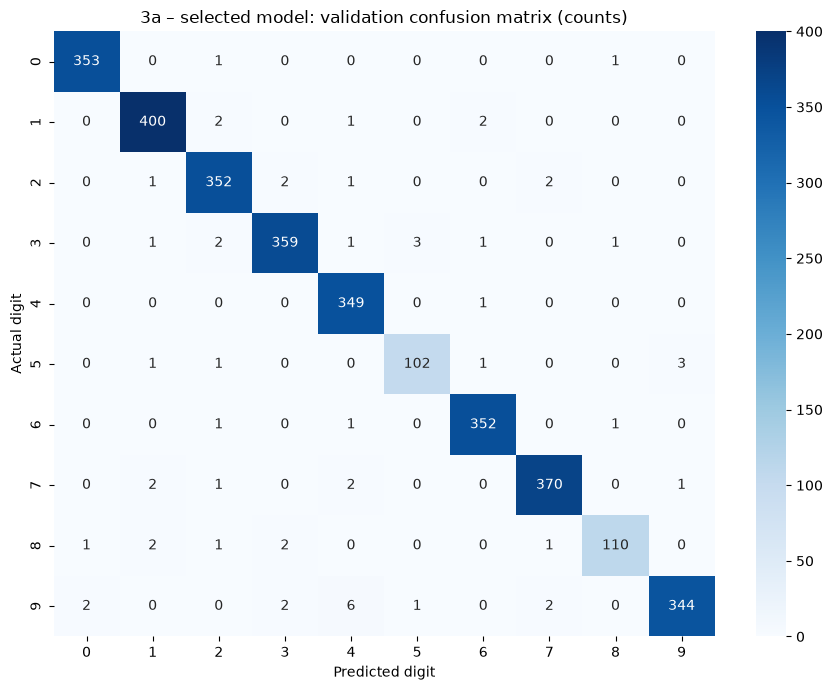

In [4]:
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.heatmap(
    best_result["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10),
)
plt.xlabel("Predicted digit")
plt.ylabel("Actual digit")
plt.title("3a – selected model: validation confusion matrix (counts)")
plt.tight_layout()
plt.show()


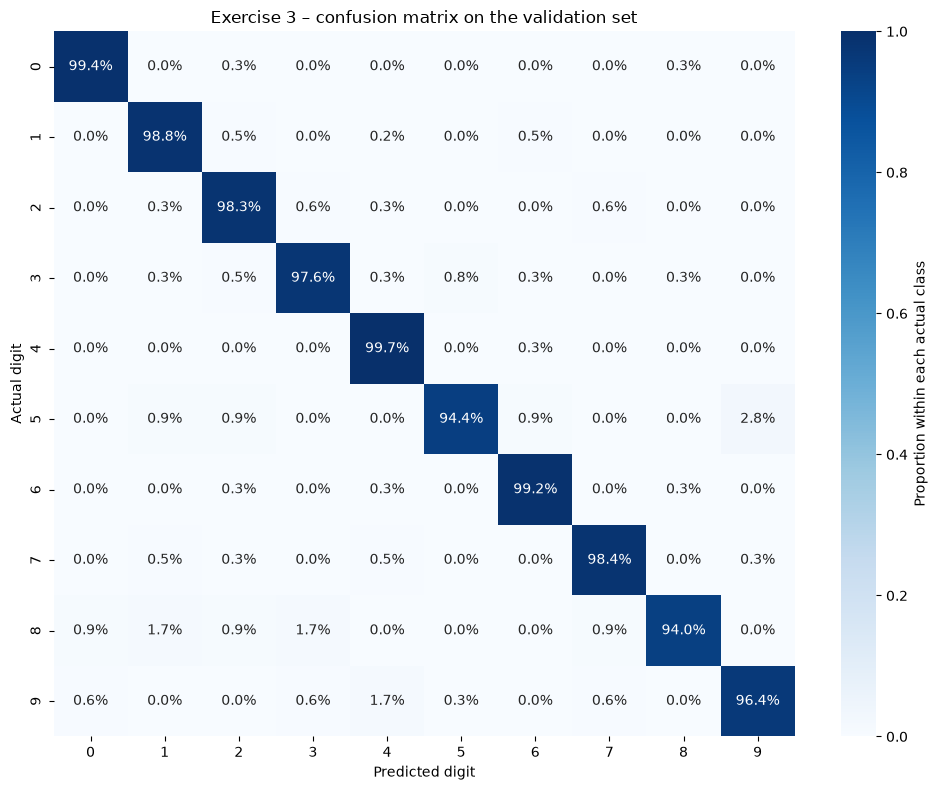

In [5]:
import numpy as np

cm = np.array(best_result["confusion_matrix"])
row_totals = cm.sum(axis=1, keepdims=True)

cm_normalized = np.divide(
    cm,
    row_totals,
    out=np.zeros_like(cm, dtype=float),
    where=row_totals != 0,
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=range(10),
    yticklabels=range(10),
    cbar_kws={"label": "Proportion within each actual class"},
)
plt.xlabel("Predicted digit")
plt.ylabel("Actual digit")
plt.title("Exercise 3 – confusion matrix on the validation set")
plt.tight_layout()
plt.show()

## 3b – Techniques evaluated to improve performance

We first applied the selected Exercise 2 configuration to `more_digits.csv`
to establish a baseline. It achieved 97.14% validation accuracy.

Keeping that configuration fixed, we evaluated changes to the training data:

| Training-data variant | Validation accuracy |
|---|---:|
| Baseline | 97.14% |
| Additional unique images | 96.95% |
| Oversampling | 96.86% |
| Additional images and oversampling | 97.05% |

These changes did not improve overall accuracy with the baseline
configuration and seed 0.

We then explored different architectures, optimizers, learning rates,
activation parameters and training durations. A configuration using Adam,
hidden layers [256, 128], additional data and oversampling achieved 97.59%
validation accuracy with beta = 0.5. Changing only beta to 1.0 increased
accuracy to 97.78%.

Finally, we introduced one-pixel translation augmentation:

| Selected Adam configuration | Validation accuracy |
|---|---:|
| Without augmentation, 60 epochs | 97.78% |
| With augmentation, 60 epochs | 97.62% |
| With augmentation, 30 epochs | 98.16% |

In the augmented 60-epoch run, training loss remained low, while
validation loss fluctuated and ended higher than at epoch 30.
This suggested that further training was not improving generalization.
We therefore tested 30 epochs, which gave better validation accuracy
for seed 0: 98.16%, compared with 97.62% after 60 epochs.

Augmentation combined with the shorter training duration produced the
best result among the evaluated configurations. However, augmentation
and oversampling also increase the number of weight updates per epoch.
The improvement cannot be attributed solely to image variation or
class balancing.

In [6]:
from pathlib import Path
import json
import pandas as pd

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent

def show_comparison(title, experiments):
    rows = []

    for label, directory in experiments:
        run_dir = root / "results" / "ex3" / directory
        files = list(run_dir.glob("*.json"))

        if len(files) != 1:
            raise ValueError(
                f"Expected one JSON result in {run_dir}, found {len(files)}"
            )

        saved = json.loads(files[0].read_text())
        config = saved["config"]
        result = saved["result"]
        extra = config.get("extra", {})

        rows.append({
            "variant": label,
            "layers": str(config["hidden_layers"]),
            "optimizer": config["optimizer_method"],
            "learning_rate": config["learning_rate"],
            "beta": config["activation_parameter"],
            "batch_size": config["batch_size"],
            "epochs": config["epochs"],
            "extra_data": bool(extra.get("extra_dataset")),
            "oversampling": extra.get("oversample", False),
            "augmentation": extra.get("augment", False),
            "validation_accuracy_percent": 100 * result["accuracy"],
        })

    print(title)
    table = pd.DataFrame(rows)

    table["learning_rate"] = table["learning_rate"].map(
        lambda value: f"{value:.5f}"
    )
    table["beta"] = table["beta"].map(
        lambda value: f"{value:.1f}"
    )
    table["validation_accuracy_percent"] = (
        table["validation_accuracy_percent"].round(2)
    )

    display(table)


### 3b.1 – Additional data and oversampling

All network hyperparameters are fixed to the Exercise 2 configuration. None of these variants improved overall validation accuracy in this run.

In [7]:
show_comparison("1. Training-data changes with the Exercise 2 configuration", [
    ("Baseline", "ex2_config_baseline"),
    ("Additional data", "ex2_config_extra_data"),
    ("Oversampling", "ex2_config_oversampled"),
    ("Additional data + oversampling", "ex2_config_extra_oversampled"),
])

1. Training-data changes with the Exercise 2 configuration


,variant,layers,optimizer,learning_rate,beta,batch_size,epochs,extra_data,oversampling,augmentation,validation_accuracy_percent
0,Baseline,[128],gradient_descent,1.00000,1.0,8,50,False,False,False,97.14
1,Additional data,[128],gradient_descent,1.00000,1.0,8,50,True,False,False,96.95
2,Oversampling,[128],gradient_descent,1.00000,1.0,8,50,False,True,False,96.86
3,Additional data + oversampling,[128],gradient_descent,1.00000,1.0,8,50,True,True,False,97.05


### 3b.2 – Architecture

We changed the first hidden layer from 64 to 128 neurons. Validation accuracy increased from 95.68% to 96.51% with the other listed settings fixed.

In [8]:
show_comparison("2. Architecture comparison", [
    ("Hidden layers [64, 64]", "adam_h64-64_70epochs"),
    ("Hidden layers [128, 64]", "adam_h128-64_70epochs"),
])

2. Architecture comparison


,variant,layers,optimizer,learning_rate,beta,batch_size,epochs,extra_data,oversampling,augmentation,validation_accuracy_percent
0,"Hidden layers [64, 64]","[64, 64]",adam,0.00100,0.5,32,70,False,False,False,95.68
1,"Hidden layers [128, 64]","[128, 64]",adam,0.00100,0.5,32,70,False,False,False,96.51


### 3b.3 – Learning rate

Reducing the learning rate gave a small change from 96.51% to 96.57%. With one seed, this is insufficient evidence of a reliable improvement.

In [9]:
show_comparison("3. Learning-rate comparison", [
    ("Learning rate 0.001", "adam_h128-64_70epochs"),
    ("Learning rate 0.0005", "adam_lr0005_h128-64_70epochs"),
])

3. Learning-rate comparison


,variant,layers,optimizer,learning_rate,beta,batch_size,epochs,extra_data,oversampling,augmentation,validation_accuracy_percent
0,Learning rate 0.001,"[128, 64]",adam,0.00100,0.5,32,70,False,False,False,96.51
1,Learning rate 0.0005,"[128, 64]",adam,0.00050,0.5,32,70,False,False,False,96.57


### 3b.4 – Activation parameter

Changing beta from 0.5 to 1.0 increased validation accuracy from 97.59% to 97.78% in this configuration.

In [10]:
show_comparison("4. Activation-parameter comparison", [
    ("Beta 0.5", "adam_h256-128_extra_oversampled_60epochs"),
    ("Beta 1.0", "adam_best_beta1"),
])

4. Activation-parameter comparison


,variant,layers,optimizer,learning_rate,beta,batch_size,epochs,extra_data,oversampling,augmentation,validation_accuracy_percent
0,Beta 0.5,"[256, 128]",adam,0.00050,0.5,32,60,True,True,False,97.59
1,Beta 1.0,"[256, 128]",adam,0.00050,1.0,32,60,True,True,False,97.78


### 3b.5 – Augmentation and training duration

Compare augmentation at a fixed 60 epochs, then compare training duration with augmentation fixed. The shorter augmented run obtained the highest observed validation accuracy.

In [11]:
show_comparison("5. Augmentation and training duration", [
    ("No augmentation, 60 epochs", "adam_best_beta1"),
    ("Augmentation, 60 epochs", "adam_beta1_augmented"),
    ("Augmentation, 30 epochs", "adam_beta1_augmented_30epochs"),
])

5. Augmentation and training duration


,variant,layers,optimizer,learning_rate,beta,batch_size,epochs,extra_data,oversampling,augmentation,validation_accuracy_percent
0,"No augmentation, 60 epochs","[256, 128]",adam,0.00050,1.0,32,60,True,True,False,97.78
1,"Augmentation, 60 epochs","[256, 128]",adam,0.00050,1.0,32,60,True,True,True,97.62
2,"Augmentation, 30 epochs","[256, 128]",adam,0.00050,1.0,32,30,True,True,True,98.16


### 3b.6 – Learning curves and the choice of 30 epochs

The first figure describes the selected 30-epoch run. The second shows the longer run that motivated trying fewer epochs. Increasing validation loss during later training, despite low training loss, suggested overfitting. We chose a fixed training duration manually; automatic early stopping was not implemented.

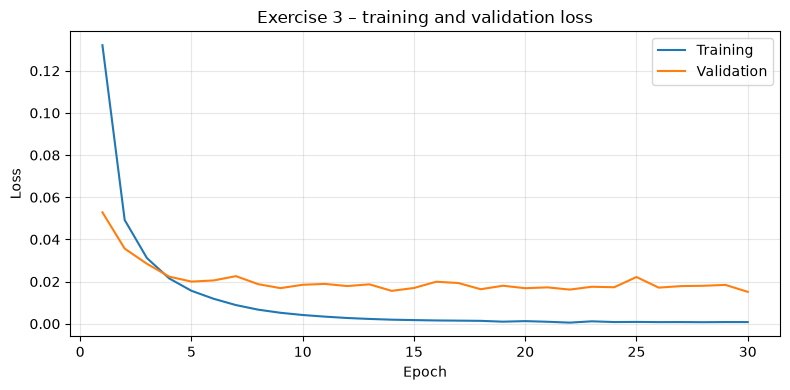

In [12]:
import matplotlib.pyplot as plt

best_path = next(
    (
        root / "results" / "ex3"
        / "adam_beta1_augmented_30epochs"
    ).glob("*.json")
)
saved = json.loads(best_path.read_text())
best_result = saved["result"]

epochs = range(1, len(best_result["train_loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, best_result["train_loss"], label="Training")
plt.plot(epochs, best_result["valid_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Exercise 3 – training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

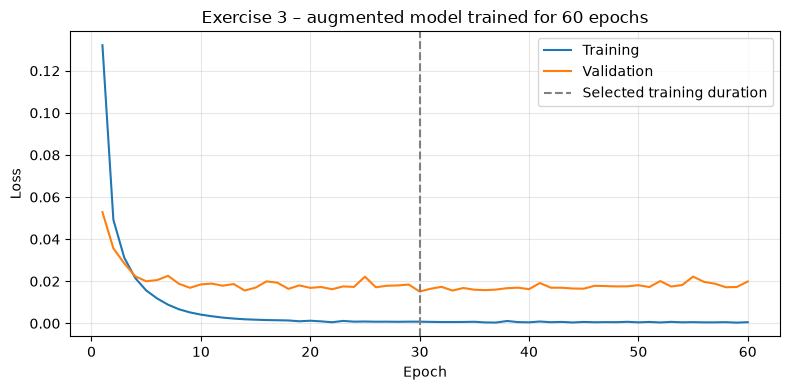

In [13]:
path_60 = next(
    (root / "results" / "ex3" / "adam_beta1_augmented").glob("*.json")
)
result_60 = json.loads(path_60.read_text())["result"]

epochs_60 = range(1, len(result_60["train_loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_60, result_60["train_loss"], label="Training")
plt.plot(epochs_60, result_60["valid_loss"], label="Validation")
plt.axvline(
    30, color="gray", linestyle="--", label="Selected training duration"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Exercise 3 – augmented model trained for 60 epochs")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3b.7 – Class-specific comparison with the baseline

All numbers below are validation results. The final model changes several settings, so this comparison does not isolate the optimizer effect.

In [14]:
comparison = []

for experiment in [
    "ex2_config_baseline",
    "ex2_config_extra_data",
    "ex2_config_oversampled",
    "ex2_config_extra_oversampled",
    "adam_beta1_augmented_30epochs",
]:
    path = next((root / "results" / "ex3" / experiment).glob("*.json"))
    result = json.loads(path.read_text())["result"]

    comparison.append({
        "experiment": experiment,
        "accuracy_percent": 100 * result["accuracy"],
        "recall_5_percent": 100 * result["recall"][5],
        "recall_8_percent": 100 * result["recall"][8],
    })

display(pd.DataFrame(comparison).round(2))

,experiment,accuracy_percent,recall_5_percent,recall_8_percent
0,ex2_config_baseline,97.14,89.81,90.60
1,ex2_config_extra_data,96.95,87.96,82.91
2,ex2_config_oversampled,96.86,87.96,90.60
3,ex2_config_extra_oversampled,97.05,90.74,88.03
4,adam_beta1_augmented_30epochs,98.16,94.44,94.02


### 3b.8 – Complete experiment record

The table is sorted by validation accuracy, not chronological order. The sequential baseline uses a different split. The final_seed1 and final_seed2 rows use different stratified splits; compare their variability separately in 3a. Optimizer experiments changed other settings too and do not establish an optimizer-only effect.

In [15]:
from pathlib import Path
import json
import pandas as pd

# Works when the notebook runs from the project root or notebooks/.
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent

rows = []

for path in sorted((root / "results" / "ex3").rglob("*.json")):
    saved = json.loads(path.read_text())
    config = saved["config"]
    result = saved["result"]
    extra = config.get("extra", {})

    rows.append({
        "experiment": path.parent.name,
        "layers": str(config["hidden_layers"]),
        "optimizer": config["optimizer_method"],
        "learning_rate": config["learning_rate"],
        "epochs": config["epochs"],
        "split": extra.get("split", "sequential"),
        "extra_data": bool(extra.get("extra_dataset")),
        "oversampling": extra.get("oversample", False),
        "accuracy_percent": 100 * result["accuracy"],
        "final_valid_loss": result["valid_loss"][-1],
        "seconds": result["total_seconds"],
        "activation_parameter": config["activation_parameter"],
        "augmentation": extra.get("augment", False),
    })

results = pd.DataFrame(rows).sort_values(
    "accuracy_percent", ascending=False
)

results = results[
    ~results["experiment"].isin([
        "best_saved",
        "ex2_config_baseline_saved",
    ])
]

table = results.copy()
table["learning_rate"] = table["learning_rate"].map(lambda x: f"{x:.5f}")
display(table.round(4))

,experiment,layers,optimizer,learning_rate,epochs,split,extra_data,oversampling,accuracy_percent,final_valid_loss,seconds,activation_parameter,augmentation
2,adam_beta1_augmented_30epochs,"[256, 128]",adam,0.00050,30,stratified,True,True,98.1581,0.0151,115.8082,1.0,True
22,final_seed2,"[256, 128]",adam,0.00050,30,stratified,True,True,97.9041,0.0178,117.8444,1.0,True
0,adam_best_beta1,"[256, 128]",adam,0.00050,60,stratified,True,True,97.7771,0.0212,129.5350,1.0,False
1,adam_beta1_augmented,"[256, 128]",adam,0.00050,60,stratified,True,True,97.6183,0.0199,268.0737,1.0,True
7,adam_h256-128_extra_oversampled_60epochs,"[256, 128]",adam,0.00050,60,stratified,True,True,97.5865,0.0218,112.6899,0.5,False
6,adam_h256-128_extra_data_60epochs,"[256, 128]",adam,0.00050,60,stratified,True,False,97.4913,0.0217,90.0549,0.5,False
21,final_seed1,"[256, 128]",adam,0.00050,30,stratified,True,True,97.4913,0.0207,109.8780,1.0,True
3,adam_beta1_lr000025,"[256, 128]",adam,0.00025,60,stratified,True,True,97.3960,0.0228,127.7049,1.0,False
5,adam_h256-128_extra_data,"[256, 128]",adam,0.00050,70,stratified,True,False,97.2055,0.0224,98.3680,0.5,False
16,ex2_config_baseline,[128],gradient_descent,1.00000,50,stratified,False,False,97.1419,0.0276,18.4024,1.0,False


## 3c – Other factors affecting the change in performance

An important difference between the datasets is class coverage:
`digits.csv` contains no examples of digit 8, whereas `more_digits.csv`
includes all ten digit classes. The original dataset contains 12,449
images, while the new dataset contains 15,741 images.

The Exercise 2 models achieved a mean test accuracy of 86.61% across
three seeds and 0% recall for digit 8. Using the same hyperparameters
on the new dataset, the Exercise 3 baseline achieved 96.08% test accuracy
and 90.95% recall for digit 8 with seed 0.

This comparison suggests that the improved training data contributed
substantially to performance before introducing the additional techniques.
However, it compares a three-seed mean with a single run, and multiple
dataset properties changed simultaneously.

Class imbalance remains relevant. Digits 5 and 8 are less represented
than most other classes. The test set also has a different class
distribution from the validation set, so overall accuracy depends partly
on the proportion of each class.

The original and new training datasets overlap. We excluded duplicate
images when adding data and excluded additional images already present
in the validation set to avoid direct leakage.

### Evaluation limitations

Configurations were compared using validation results. However, the test
set was evaluated for earlier models before development was complete.
The final 98.12% result is therefore a follow-up evaluation on a previously
observed test set, rather than a completely untouched final evaluation.

Repeated adaptive comparisons on the same validation split can also
produce optimistic estimates. The three-seed evaluation in 3a demonstrates variation: test accuracy ranged from 97.36% to 98.12%. The seed changes both the split and training randomness. Three runs provide a limited estimate; fresh unseen data would strengthen the conclusions.

### 3c.1 – Class distribution in the provided datasets

This table documents class coverage and imbalance. See ex3_data_exploration.ipynb for the broader data exploration.

In [16]:
class_counts = {}
for name in ["digits", "more_digits", "digits_test"]:
    labels = pd.read_csv(root / "data" / f"{name}.csv", usecols=["label"])["label"]
    class_counts[name] = labels.value_counts().reindex(range(10), fill_value=0)
class_table = pd.DataFrame(class_counts)
class_table.index.name = "digit"
display(class_table)
print("Total images:")
print(class_table.sum().to_string())


,digits,more_digits,digits_test
digit,,,
0,1480,1776,245
1,1685,2022,283
2,1489,1787,258
3,1532,1839,252
4,1460,1752,245
5,271,542,223
6,1479,1775,239
7,1566,1879,257
8,0,585,243


Total images:
digits         12449
more_digits    15741
digits_test     2497
